# 00. Homework description

For this assignment, your task is to develop the [FastPitch](https://arxiv.org/abs/2006.06873) synthesis model, train it, and generate several audio samples.

The training and data processing code has already been provided for you. The training will be conducted on the LJspeech dataset.

The total score for the homework is **10 points**, distributed as follows:
- 1 point for visualizing the input data
- 8 points for writing the model code and running training
- 1 point for pitch and duration manipulations during inference

The homework submission **should include**:
- Completed notebook
- Attached WER and loss graphs from TensorBoard
- 1 audio file - the result of a regular model inference
- 4 additional audio files: you are encouraged to experiment with adjusting phoneme durations and pitch slightly and listen to the results.

# 01. Preparation steps

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
device = "cuda"
gpu_avaiable = "1"    # Run nvidia-smi to find free GPU

In [4]:
path_to_sources = '/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders'   # Path to the the current week's source code, e.g. /home/user/speech_course/week_08_tts_am_vocoders

In [5]:
# If running in colab

# clone the repository:
# git clone https://github.com/yandexdataschool/speech_course.git
%pip install -r /home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/requirements.txt
%pip install ipython==8.21.0


[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


### Dataset

We will work with [LJSpeech](https://keithito.com/LJ-Speech-Dataset/) -- a single-speaker dataset with 24 hours of speech.

The data we will use contains pre-computed [MFA-alignments](https://montreal-forced-aligner.readthedocs.io/en/latest/user_guide/workflows/alignment.html) alongside with the original wavs and texts. If you are interested in the process of extracting such alignments, please refer to this [tutorial](https://colab.research.google.com/gist/NTT123/12264d15afad861cb897f7a20a01762e/mfa-ljspeech.ipynb).

Download the dataset with precomputed alignments.

In [4]:
import requests
from urllib.parse import urlencode
from io import BytesIO
from zipfile import ZipFile

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
public_key = 'https://disk.yandex.ru/d/PpgePfWcQTAbug'

final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']
response = requests.get(download_url)

path_to_dataset = '/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/ljspeech'    # Choose any appropriate local path

# If running in Colab:
# path_to_dataset = '/content/ljspeech_aligned'

zipfile = ZipFile(BytesIO(response.content))
zipfile.extractall(path=path_to_dataset)

### Hi-Fi GAN checkpoint


Download a pretrained Hi-Fi GAN checkpoint (to generate audio from the predicted mel-spectrograms).

In [ ]:
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O hifigan_ckpt.zip
!unzip hifigan_ckpt.zip
!rm hifigan_ckpt.zip

In [ ]:
# In colab:
# !wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/dle/hifigan__pyt_ckpt_ds-ljs22khz/versions/21.08.0_amp/zip -O /content/hifigan_ckpt.zip
# !unzip /content/hifigan_ckpt.zip
# !rm /content/hifigan_ckpt.zip

In [6]:
path_to_hfg_ckpt = "/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/notebooks/hifigan_gen_checkpoint_6500.pt"
path_to_dataset = '/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/ljspeech'    # Choose any appropriate local path


### Imports

In [7]:
import sys
import os
import json
import dataclasses
import torch
import subprocess as sp
import matplotlib.pylab as plt
import soundfile as sf

from g2p_en import G2p
import IPython.display as Ipd

In [8]:
sys.path.append(path_to_sources)

# 02. See a data sample (1 point)

In [9]:
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.data import prepare_loaders, SymbolsSet

The mfa alignment provides phonemes and their durations, which we will need during training:

In [ ]:
with open(os.path.join(path_to_dataset, 'mfa_aligned', 'LJ001-0001.json')) as f:
    utterance = json.load(f)

utterance

Phoneme `sil` here denotes pause -- a period of silence between spoken phonemes. The phonemes are from [ARPA](https://en.wikipedia.org/wiki/ARPABET) alphabet.

In [10]:
hparams = HParamsFastpitch()
train_loader, val_loader = prepare_loaders(path_to_dataset, hparams)

In [12]:
train_iter = iter(train_loader)
batch = next(train_iter)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [13]:
list(dataclasses.asdict(batch).keys())

['texts',
 'text_lengths',
 'mels',
 'mel_lengths',
 'pitches',
 'durations',
 'paces']

In [18]:
batch.mels.shape

torch.Size([10, 80, 832])

In [19]:
batch.pitches.shape

torch.Size([10, 99])

In [20]:
batch.durations.shape

torch.Size([10, 99])

In [32]:
batch.mels[0][0][470:485]

tensor([-6.3681, -6.6716, -7.5516, -7.4481, -7.4211, -7.2356, -7.2808, -7.4808,
        -7.2847, -6.9732,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000])

In [68]:
torch.sum(batch.durations[0] != 0)

tensor(76)

In [45]:
batch.pitches[0]

tensor([ 0.6619,  0.3641,  0.3159, -0.0368,  0.0000,  1.1142,  1.3194,  1.5762,
         0.8725, -0.6613, -0.3370, -0.4031, -0.9874, -0.9888, -1.0512, -0.5147,
         0.0000, -0.1846, -0.0820,  0.0000, -0.2690, -0.8675, -0.9837, -1.0660,
        -1.0987, -1.1679, -1.2581,  0.0000, -0.3330,  1.1001, -0.0945,  0.0000,
         0.0000, -1.1290, -0.1612,  0.0000,  0.0000, -0.0934, -0.1291,  0.4835,
         0.4847,  0.4323,  0.6137, -0.2539, -0.6200, -0.0998, -0.0259,  0.1028,
        -0.2130, -0.4431, -0.1496, -0.4203, -0.7623, -0.1197, -0.2023,  0.0000,
        -0.3451, -0.7429, -0.0891,  0.0413, -0.9340, -0.4673,  0.0000,  0.0000,
         0.1651,  0.2080,  0.0000,  0.4643,  0.7851,  0.0409,  0.2538, -0.0751,
         0.0000, -0.0265, -0.4856, -0.6889, -0.4864, -0.7588, -0.2869, -1.0602,
        -1.2726,  0.0000, -0.4006, -1.3330, -0.5007,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000])

In [48]:
val_loader.dataset[0]['mel'].shape

(80, 139)

In [21]:
PITCH_MEAN=215.42230    # LJSpeech constants, in practice depend on the dataset
PITCH_STD=62.51305

In [13]:
import numpy as np

def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

mel_min = hz_to_mel(0)   
mel_max = hz_to_mel(8000) 

def pitch_to_mel_bin(mel, n_mels=80):
    mel_bin = (mel - mel_min) / (mel_max - mel_min) * (n_mels - 1)
    return mel_bin

## Task

**(0.5 points)** Draw a combined image showing both the mel-spectrogram and pitch for a sample from the batch. Use durations to ensure proper alignment of their shapes in the image.  
**(0.5 points)** Include phoneme labels near the time axis on the image from the previous step. (like in Figure 3 in the [paper](https://arxiv.org/pdf/2006.06873.pdf)). You may find the code from the seminar helpful.

## Важно!!!!!!!!

Я поменял индекс паддинга для символов с нуля на другой (немного пошаманил с кодом в сурсах, добавил паддинг-фонему в словарь)

In [23]:
def plot_segments(mel, pitches, durations, symbols):
    unnormed_pitches = pitches * PITCH_STD + PITCH_MEAN
    pitch_to_mels = pitch_to_mel_bin(unnormed_pitches).numpy()
    
    unpadded_durations_len = torch.sum(durations != 0).item()
    summar_len = torch.sum(durations).item()
    durated = np.repeat(pitch_to_mels[:unpadded_durations_len], durations[:unpadded_durations_len].numpy())
    plt.figure(figsize=(30, 15))
    plt.imshow(mel[:,:summar_len], origin='lower')
    plt.scatter(x=np.arange(0, summar_len), y=durated, s=1, c='r')
    durations_cs = np.hstack([[0], durations[:unpadded_durations_len].numpy().cumsum()])

    for i, s in enumerate(durations_cs[:-1]):
        shift = 3 #-5 if i % 2 else 15
        plt.text(
            s, shift * 1,# * 20,
            symbols[i],
            fontsize=7,
            weight='bold',
            rotation=90
        )

    for s in durations_cs:
        plt.axvline(x=s, c='r')
        
    plt.savefig('lol.jpg')
        


In [24]:
test_id = 4

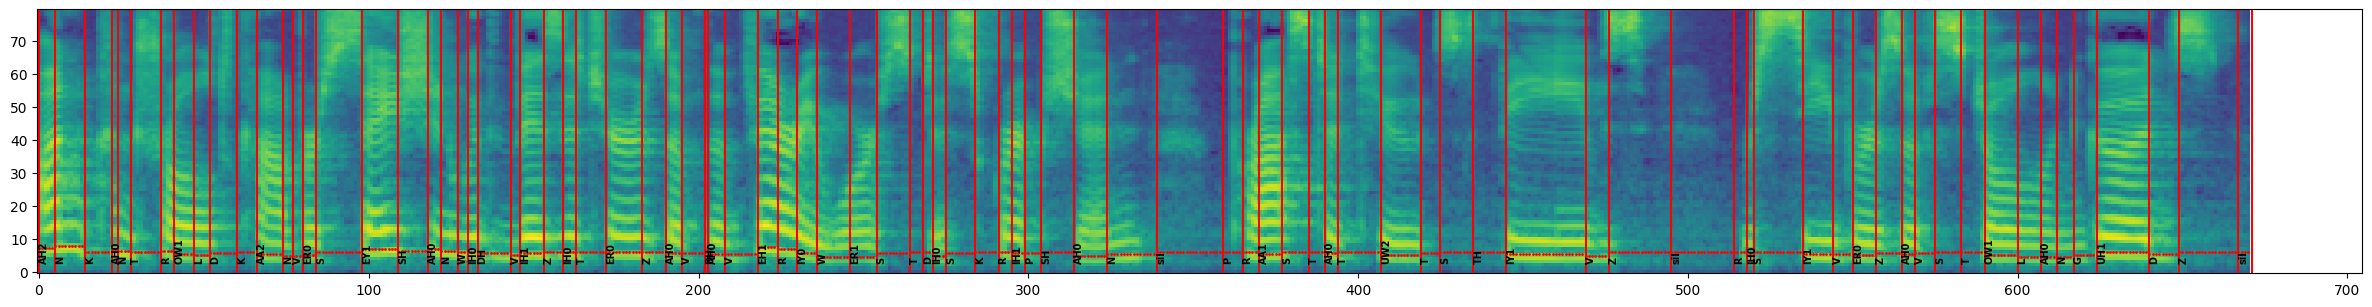

In [159]:
plot_segments(batch.mels[test_id], batch.pitches[test_id], batch.durations[test_id], SymbolsSet().decode(batch.texts[test_id].tolist()))

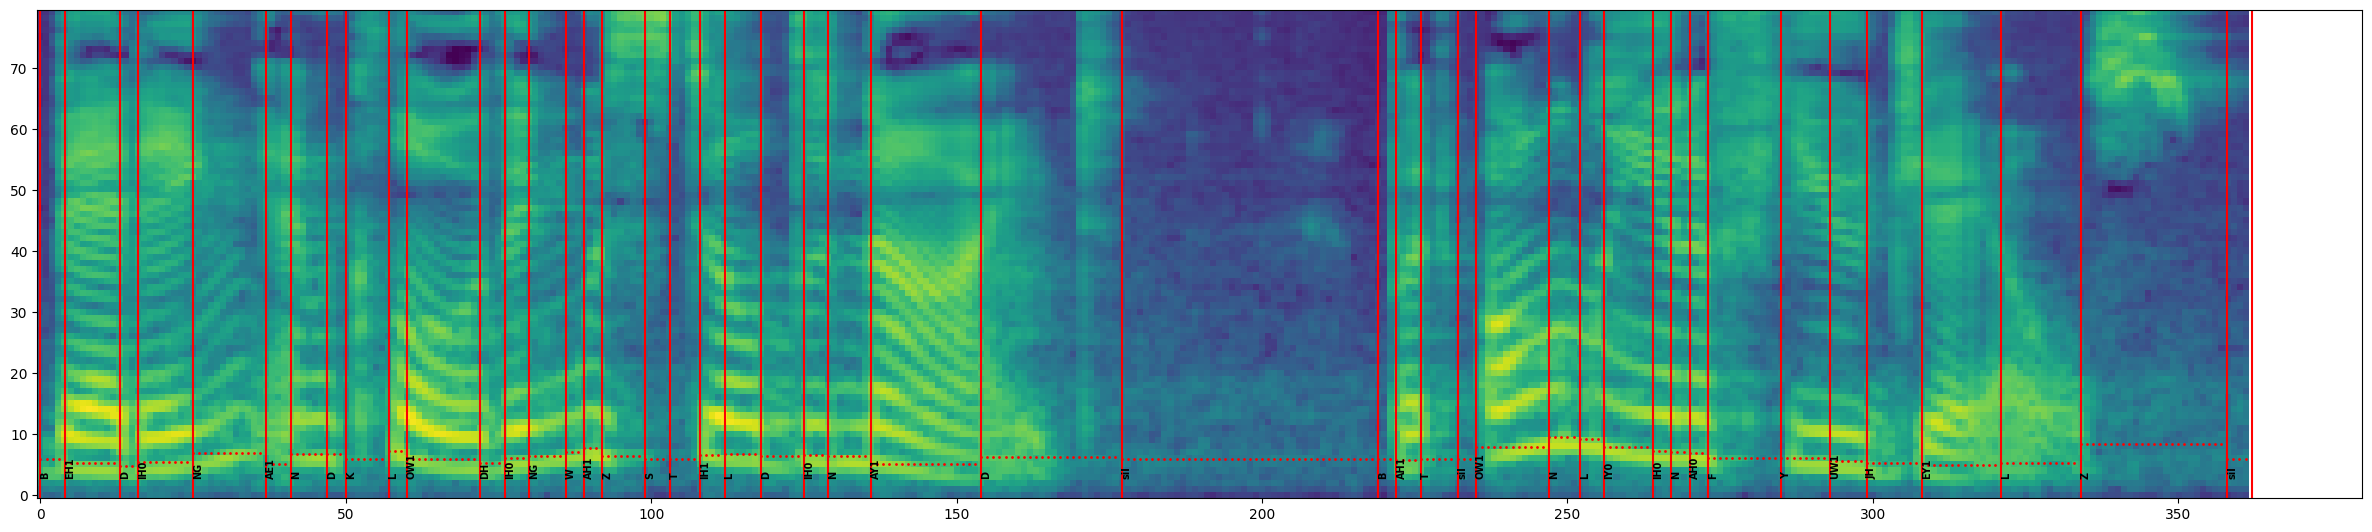

In [25]:
plot_segments(batch.mels[test_id], batch.pitches[test_id], batch.durations[test_id], SymbolsSet().decode(batch.texts[test_id].tolist()))

# 03. Implement FastPitch model (9 points)

Please implement the FastPitch model in the cell provided below. Running this cell will overwrite the model file in the repository. 
- Run training (see next cells)
- Run inference (see next cells)
- When submitting the homework, please include
   - the Word Error Rate (WER) and loss curves obtained from TensorBoard as attachments,
   - the generated audio (see inference cells). If attaching an archive, use the name: `prediction.wav`

By the end of training, the loss should reach approximately 0.69, and WER should be close to zero (around 0.006). The training process will take about 30 minutes (3,000 batches).

**Important:** By the end of the training, the generated audio sample must be clear in terms of speech (WER close to 0) and maintain audio quality comparable to the original recordings (as logged in TensorBoard). **If these conditions are not met, the entire section will receive zero points**, regardless of how closely the model code resembles working code. Here is an example of how an audio from a well-trained model may sound:

In [14]:
audio, sr = sf.read('prediction_example.wav')
Ipd.display(Ipd.Audio(audio, rate=sr))

In [15]:
%%writefile /home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/sources/fastpitch/model.py

import torch
from torch import nn as nn

from sources.fastpitch.common.layers import TemporalPredictor
from sources.fastpitch.common.utils import DeviceGetterMixin
from sources.fastpitch.common.utils import regulate_len
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.fastpitch.hparams import HParamsFastpitch
from sources.fastpitch.common.transformer import FFTransformer


class FastPitch(nn.Module, DeviceGetterMixin):
    def __init__(self, hparams: HParamsFastpitch):
        super().__init__()
        self.hparams = hparams
        n_symbols = len(SymbolsSet().symbols_to_id)
        self.padding_idx = SymbolsSet().symbols_to_id['<PAD>']
        self.symbol_emb = nn.Embedding(n_symbols, hparams.symbols_embedding_dim)

        self.encoder = FFTransformer(
            n_layer=hparams.in_fft_n_layers,
            n_head=hparams.in_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.in_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.in_fft_conv1d_kernel_size,
            dropout=hparams.p_in_fft_dropout,
            dropatt=hparams.p_in_fft_dropatt,
            dropemb=hparams.p_in_fft_dropemb
        )

        self.duration_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.dur_predictor_filter_size,
            kernel_size=hparams.dur_predictor_kernel_size,
            dropout=hparams.p_dur_predictor_dropout,
            n_layers=hparams.dur_predictor_n_layers
        )

        self.pitch_predictor = TemporalPredictor(
            input_size=hparams.symbols_embedding_dim,
            filter_size=hparams.pitch_predictor_filter_size,
            kernel_size=hparams.pitch_predictor_kernel_size,
            dropout=hparams.p_pitch_predictor_dropout,
            n_layers=hparams.pitch_predictor_n_layers
        )

        self.pitch_emb = nn.Conv1d(1, hparams.symbols_embedding_dim, kernel_size=3, padding=1)

        self.decoder = FFTransformer(
            n_layer=hparams.out_fft_n_layers,
            n_head=hparams.out_fft_n_heads,
            d_model=hparams.symbols_embedding_dim,
            d_head=hparams.out_fft_d_head,
            d_inner=4 * hparams.symbols_embedding_dim,
            kernel_size=hparams.out_fft_conv1d_kernel_size,
            dropout=hparams.p_out_fft_dropout,
            dropatt=hparams.p_out_fft_dropatt,
            dropemb=hparams.p_out_fft_dropemb
        )

        self.proj = nn.Linear(hparams.symbols_embedding_dim, hparams.n_mel_channels, bias=True)

    def get_encoder_out(self, batch: FastPitchBatch):
        '''
        Return: 
        enc_out: 
            Output of the first series of FFT blocks (before adding pitch embedding)
            shape: (batch, len(text), symbols_embedding_dim)
        enc_mask:
            Boolean padding mask for the input text sequences
            shape: (batch, len(text), 1)
        '''
        emb = self.symbol_emb(batch.texts)
        enc_mask = (batch.texts != self.padding_idx).unsqueeze(2)
        enc_out, _ = self.encoder(emb, batch.text_lengths)
        return enc_out, enc_mask

    def forward(self, batch: FastPitchBatch, use_gt_durations=True, use_gt_pitch=True, max_duration=75):
        '''
        Flags `use_gt_durations` and `use_gt_pitch` should be both True during training and either True or False during inference.

        Use the function `regulate_len` to duplicate phonemes according to durations before passing them to the decoder.
        
        Return:
        mel_out:
            Predicted mel-spectrograms
            shape: (batch, time, mel_bins)
        mel_lens:
            Number of time frames in each of the predicted spectrograms
            shape: (batch,)
        log_dur_pred:
            The predicted log-durations for each phoneme (the output of the duration predictor).
            shape: (batch, len(text))
        dur_pred:
            The exponent of the predicted log-durations for each phoneme. Clamped to the range (0, max_duration) for numeric stability
            shape: (batch, len(text))
        pitch_pred:
            The predicted pitch for each phoneme
            shape: (batch, len(text))
        '''
        enc_out, enc_mask = self.get_encoder_out(batch)     
        pitch_pred = self.pitch_predictor(enc_out, enc_mask)
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred), 0, max_duration)
        
        if use_gt_pitch:
            pitches = batch.pitches.unsqueeze(1)
        else:
            pitches = pitch_pred.unsqueeze(1)
        
                    
        if use_gt_durations:
            durations = batch.durations
        else:
            durations = dur_pred
            
        no_repeat_embs = self.pitch_emb(pitches).transpose(1, 2) + enc_out    
        enc_rep, mel_lens, reps = regulate_len(durations, no_repeat_embs)
        mel_out, _ = self.decoder(enc_rep, mel_lens)
        mel_out = self.proj(mel_out)
        return mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred

    @torch.no_grad()
    def infer(self, batch: FastPitchBatch, max_duration=75):
        enc_out, dur_pred, pitch_pred = self.infer_encoder(batch, max_duration=max_duration)
        mel_out, mel_lens = self.infer_decoder(enc_out, dur_pred)
        return mel_out, mel_lens, dur_pred, pitch_pred

    def infer_encoder(self, batch: FastPitchBatch, max_duration=75):
        enc_out, enc_mask = self.get_encoder_out(batch)  
        pitch_pred = self.pitch_predictor(enc_out, enc_mask).unsqueeze(1)
        log_dur_pred = self.duration_predictor(enc_out, enc_mask)
        dur_pred = torch.clamp(torch.exp(log_dur_pred), 0, max_duration)
        return self.pitch_emb(pitch_pred).transpose(1, 2) + enc_out, dur_pred, pitch_pred

    def infer_decoder(self, enc_out, dur_pred):
        enc_rep, mel_lens, reps = regulate_len(dur_pred, enc_out)
        mel_out, _ = self.decoder(enc_rep, mel_lens)
        return self.proj(mel_out), mel_lens

Overwriting /home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/sources/fastpitch/model.py


In [29]:
 # Allows reloading code import without kernel restart
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from sources.fastpitch.model import FastPitch

In [17]:
fp = FastPitch(hparams)

In [18]:
enc_out, enc_mask = fp.get_encoder_out(batch)

In [19]:
assert enc_out.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], hparams.symbols_embedding_dim])
assert enc_mask.shape == torch.Size([hparams.batch_size, batch.texts.shape[1], 1])

In [20]:
mel_out, mel_lens, dur_pred, log_dur_pred, pitch_pred = fp.forward(batch)

In [21]:
assert mel_out.shape == batch.mels.transpose(2, 1).shape
assert mel_lens.shape == batch.mel_lengths.shape
assert dur_pred.shape == batch.texts.shape
assert dur_pred.shape == log_dur_pred.shape
assert pitch_pred.shape == batch.texts.shape

In [22]:
_, _, _ = fp.infer_encoder(batch)

### Run training

In [63]:
len(train_loader.dataset)

12807

In [23]:
torch.cuda.is_available()

True

In [18]:
logs_dir = "/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/notebooks/logs_new"     # Choose any paths
ckpt_dir = "/home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/notebooks/ckpts_new"

In [25]:
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

In [27]:
sp.check_call(
    ' '.join([
        f'PYTHONPATH={path_to_sources} CUDA_VISIBLE_DEVICES={0}',
        f'python3 -m sources.fastpitch.train_fastpitch',
        f'--logs {logs_dir}',
        f'--ckptdir {ckpt_dir}',
        f'--dataset {path_to_dataset}',
        f'--hfg {path_to_hfg_ckpt}'
    ]), shell=True
)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
18123 12 06:24:33 INFO Loaded /home/jupyter/datasphere/project/speech_course/week_08_tts_am_vocoders/notebooks/ckpts_new/fp_step_00000001.pt
/home/jupyter/.local/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")
18123 12 06:24:35 INFO Epoch num: 0


HiFi-GAN: Removing weight norm.


/home/jupyter/.local/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv1d(input, weight, bias, self.stride,
18123 12 06:24:52 INFO train : 2  loss 35.3775  elapsed 14.38  load 2.26
18123 12 06:24:52 INFO train : 3  loss 35.1554  elapsed 0.13  load 0.00
18123 12 06:24:52 INFO train : 4  loss 36.7026  elapsed 0.09  load 0.00
18123 12 06:24:52 INFO train : 5  loss 35.7617  elapsed 0.22  load 0.02
18123 12 06:24:52 INFO train : 6  loss 35.1248  elapsed 0.22  load 0.01
18123 12 06:24:53 INFO train : 7  loss 35.0118  elapsed 0.37  load 0.00
18123 12 06:24:53 INFO train : 8  loss 33.7551  elapsed 0.24  load 0.04
18123 12 06:24:53 INFO train : 9  loss 34.3131  elapsed 0.20  load 0.01
18123 12 06:24:54 INFO train : 10  loss 33.5629  elapsed

0

In [ ]:
# If running in colab:

# %%shell

# mkdir logs checkpoints

# PYTHONPATH=speech_course python3 -m week_07_tts_am.fastpitch.train_fastpitch  \
# --logs logs \
# --ckptdir checkpoints \
# --dataset /content/ljspeech_aligned \
# --hfg /content/hifigan_gen_checkpoint_6500.pt

### Infer model on an example

Execute the code provided below. Then, append the generated audio to the homework results.
- if attaching an archive, use name: `prediction.wav`

In [12]:
from sources.fastpitch.common.checkpointer import Checkpointer
from sources.fastpitch.model import FastPitch
from sources.fastpitch.data import FastPitchBatch, SymbolsSet
from sources.hifigan.model import load_model as load_hfg_model

In [13]:
def get_symbol_ids(text):
    g2p = G2p()
    phonemes = g2p(text)

    symbols_set = SymbolsSet()
    
    symbols = []
    for ph in phonemes:
        if ph in symbols_set.symbols_to_id:
            symbols.append(ph)
        elif ph == ' ':
            continue
        else:
            symbols.append("sil")
    
    symbols_ids = torch.LongTensor(symbols_set.encode(symbols))
    text_length = torch.LongTensor([symbols_ids.shape[0]])

    return symbols_ids, text_length

In [19]:
checkpointer = Checkpointer(ckpt_dir)

In [ ]:
hfg = load_hfg_model(path_to_hfg_ckpt)
hfg = hfg.to(device).eval()

In [21]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [22]:
ckpt_dict = checkpointer.load_last_checkpoint()
hparams = HParamsFastpitch.create(ckpt_dict['hparams'])
fp = FastPitch(hparams)
fp.load_state_dict(ckpt_dict['state_dict'])
fp = fp.to(device)

In [23]:
text = "Freestyler, rock the microphone, straight from the top of my dome. Freestyler, rock the microphone, carry on with the freestyler."

In [24]:
symbols_ids, lengths = get_symbol_ids(text)

batch = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths
).to(device)

In [39]:
with torch.no_grad():
    mels, mel_lens, *_ = fp.infer(batch)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))

### Pitch & duration manipulations (1 point)

- **(0.5 points)** Try increasing and decreasing the prediction speed by a factor of 2, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_half_dur.wav`,  `prediction_double_dur.wav`
- **(0.5 points)** Try shifting prediction pitch 50 Hz up and down, draw spectrograms for each case
    - if attaching an archive, use names:  `prediction_50hz_up.wav`,  `prediction_50hz_down.wav`

Аttach resulting audio files to the homework report. 

In [26]:
def scale_durations(durations: torch.Tensor, scale_factor: float):
    return durations * scale_factor


def shift_pitch(pitch: torch.Tensor, shift: float):
    scale = 62.51305    # Mean and variance of pitch in LJSpeech used for target pitch normalization
    mean = 215.42230
    unnormed = pitch * scale + mean
    unnormed += shift
    return (unnormed - mean) / scale

In [27]:
_, dur_pred, pitch_pred = fp.infer_encoder(batch)

In [33]:
dur_pred.shape, pitch_pred.shape

(torch.Size([1, 88]), torch.Size([1, 1, 88]))

In [40]:
batch_new = FastPitchBatch(
    texts=symbols_ids.unsqueeze(0),
    text_lengths=lengths,
    pitches=shift_pitch(pitch_pred.squeeze(1), shift=-50),
    durations=scale_durations(dur_pred, scale_factor=1)
).to(device)

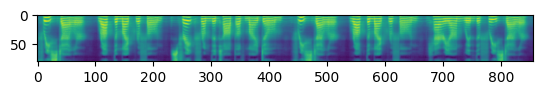

In [41]:
with torch.no_grad():
    mels, mel_lens, *_ = fp(batch_new, use_gt_durations=True, use_gt_pitch=True)
    mels = mels.permute(0, 2, 1)
    audio = hfg(mels)

Ipd.display(Ipd.Audio(audio.squeeze().cpu().detach().numpy(), rate=22050))
plt.imshow(mels.squeeze().cpu().detach().numpy())
plt.show()